In [24]:
from plastic_neuron import PlasticNeuron
from abstract_neuron import AbstractNeuron
from neuron_utils import NeuronUtils
from neuron_plots import NeuronPlots
import matplotlib.pyplot as plt
from neuron import h
import numpy as np
import pandas as pd

# Subthreshold LTP without the electric field

The neuron has 10 synapses. All synapses receive potentiating inputs of 100 Hz for 1000 ms, starting at 1000 ms and ending at 2000 ms.

The test stimulus (a single stimulus to all synapses) is provided at 100 ms (before LTP protocol) and at 2500 ms (after LTP protocol).

Goal: find such a conductance that after providing a test stimulus to all synapses, it would not elicit APs neither before nor after the LTP protocol without the electric field - but would fire during LTP. This conductance should be different for different synapse configurations.

In [25]:
test_stimulus_1 = 100
test_stimulus_2 = 2500

time_before = 50
time_after = 100

In [26]:
seed_idx = 3
seeds = pd.read_csv("output/temporal-interference/seeds.csv", index_col = 0)
seed = int(seeds.iloc[seed_idx].Seed)

In [27]:
duration = 3000
ltp_start = 1000
ltp_duration = 1000
ltp_frequency = 100

n_synapses = 10
initial_weight = 0.1

In [28]:
def generate_ltp_spike_times():
    """Generate Poisson-distributed spike times."""
    spikes = []
    t = test_stimulus_1
    spikes.append(t)

    t = ltp_start
    while t < ltp_start + ltp_duration:
        spikes.append(t)
        isi = int(1000 / ltp_frequency)
        t += isi

    t = test_stimulus_2
    spikes.append(t)

    return spikes

In [29]:
# Define the stimulus
def ltp_stimulus():
    # Generate spike times
    spike_times = generate_ltp_spike_times()

    spike_vec = h.Vector(spike_times)
    stimulus = h.VecStim()
    stimulus.play(spike_vec)

    return stimulus

In [30]:
neuron = PlasticNeuron(
    n_synapses = n_synapses,
    seed = seed,
    initial_conductance = 0,
    initial_weight = initial_weight,
    generate_stimulus = ltp_stimulus
)

Creating cell
Generating synapse information
Inserting 10 synapses


In [31]:
def find_conductance(
        min_conductance = 0.00005,
        max_conductance = 0.00015,
        epsilon: float = 0.00001,
        min_dendritic_spikes = 0.2
):
    global duration
    global ltp_start, ltp_duration
    global test_stimulus_1, test_stimulus_2
    global time_before, time_after

    # Turn off the stimulation
    NeuronUtils.set_stimulus(duration = 0)

    # Start with the average conductance value
    conductance = (min_conductance + max_conductance) / 2
    step = (max_conductance - min_conductance) / 2

    good_behavior = False
    last_conductance = conductance

    results = []

    while step * 2 > epsilon or not good_behavior:
        print(f"Testing conductance: {format(conductance, '.8f')}")
        last_conductance = conductance

        neuron.set_initial_conductance(conductance)
        neuron.run(duration = duration)

        spike_before = np.any(
            neuron.voltage[np.logical_and(neuron.time > test_stimulus_1 - time_before, neuron.time < test_stimulus_1 + time_after)] > -20
        )
        spike_after = np.any(
            neuron.voltage[np.logical_and(neuron.time > test_stimulus_2 - time_before, neuron.time < test_stimulus_2 + time_after)] > -20
        )

        ltp_time = np.logical_and(neuron.time > ltp_start, neuron.time < ltp_start + ltp_duration)
        spike_during = np.any(
            neuron.voltage[ltp_time] > -20
        )
        dendritic_spikes = np.mean([ np.any(synapse.voltage[ ltp_time ] > -20) for synapse in neuron.synapses ])

        print(f"Spike before: {spike_before} (False)")
        print(f"Spike after: {spike_after} (False)")
        print(f"Spike during: {spike_during} (True)")
        print(f"Percentage of dendritic spikes: {round(dendritic_spikes * 100)}%")

        good_behavior = not spike_before and not spike_after and dendritic_spikes >= min_dendritic_spikes

        results.append(pd.DataFrame({
            "Conductance": [conductance],
            "SpikeBefore": [spike_before],
            "SpikeAfter": [spike_after],
            "SpikeDuring": [spike_during],
            "DendriticSpikes": [dendritic_spikes],
            "Correct": [good_behavior],
            "Step": [step]
        }))

        if spike_before or spike_after:
            conductance -= step
        if dendritic_spikes < min_dendritic_spikes:
            conductance += step

        print(f"Correct behavior: {good_behavior} (True)")
        print()
        
        if good_behavior:
            print("Correct behavior achieved")
            break

        step = step / 2

    results = pd.concat(results, ignore_index = True)

    print(f"Final conductance: {format(last_conductance, '.8f')}")
    return last_conductance, results

In [ ]:
conductance, results = find_conductance(
    min_conductance = 0.00005,
    max_conductance = 0.0001,
    epsilon = 0.0000005
)

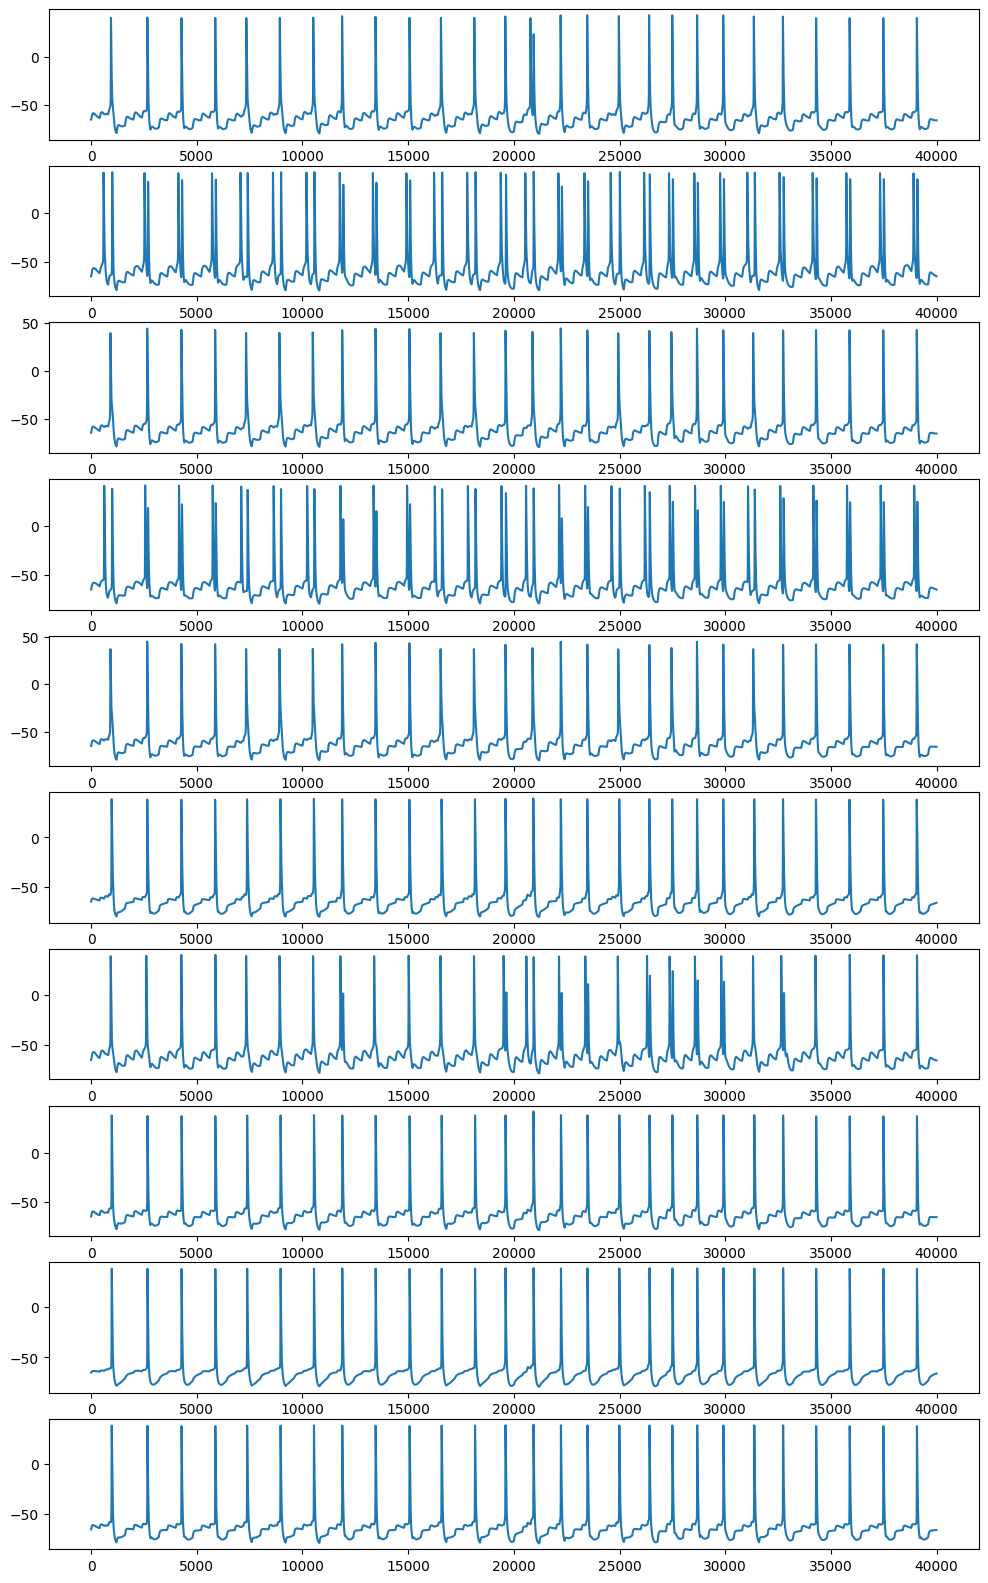

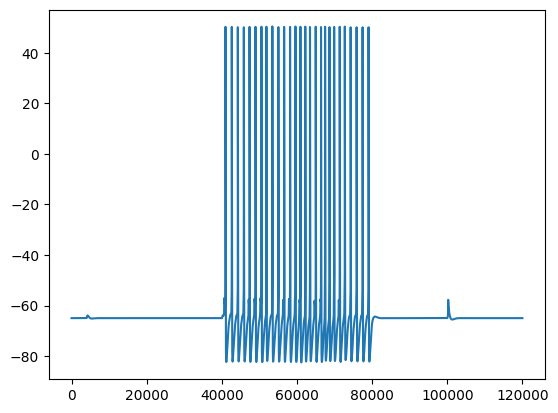

In [11]:
# Change of plans: want dendritic spikes during LTP (at least half the synapses?)
#                  and don't care whether the neuron spikes during LTP or not
ltp_time = np.logical_and(neuron.time > ltp_start, neuron.time < ltp_start + ltp_duration)
np.any(neuron.synapses[0].voltage[ ltp_time ] > -20)

fig, axs = plt.subplots(nrows = 10, ncols = 1, figsize = (12, 10 * 2))
for ax, synapse in zip(axs, neuron.synapses):
    ax.plot(
        synapse.voltage[ ltp_time ]
    )
plt.show()

# plt.plot(neuron.voltage[ltp_time])

plt.plot(neuron.voltage)

In [12]:
results

,Conductance,SpikeBefore,SpikeAfter,SpikeDuring,DendriticSpikes,Correct,Step
0,0.000075,False,False,False,0.0,False,0.000025
1,0.000100,False,True,True,1.0,False,0.000013
2,0.000087,False,False,True,1.0,True,0.000006


In [13]:
print(f"Final conductance: {format(conductance, '.10f')}")

Final conductance: 0.0000875000


In [14]:
NeuronUtils.set_stimulus(duration = 0)
neuron.set_initial_conductance(conductance)
neuron.run(duration = duration)

Neuron initialized
Elapsed time: 71.10 seconds


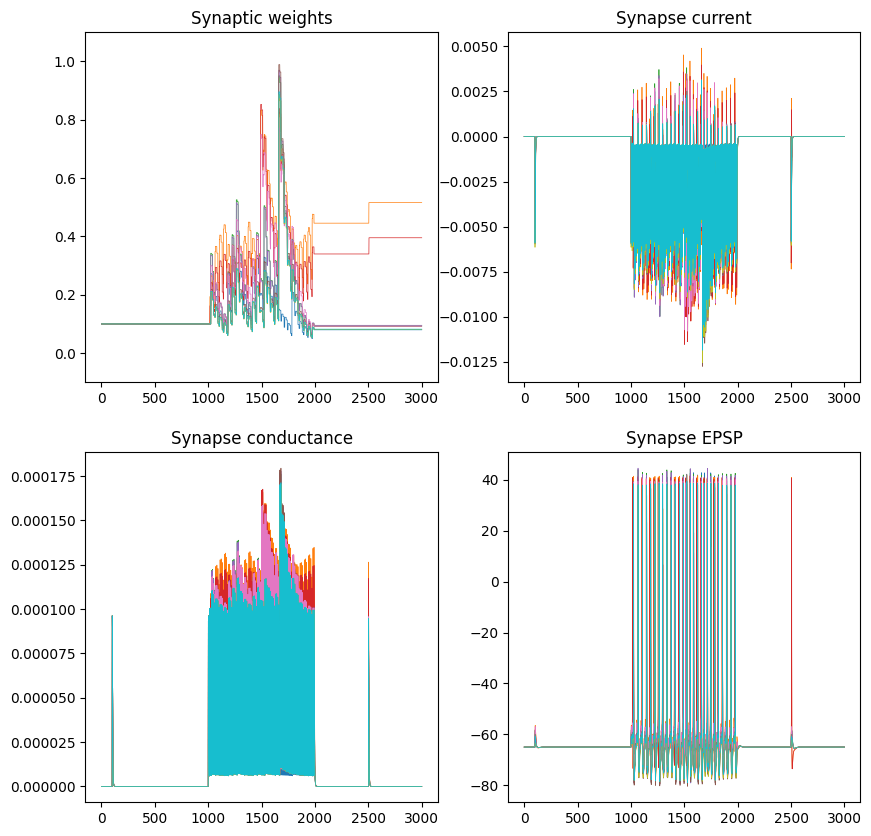

In [15]:
NeuronPlots.plot_all_synapses(neuron)

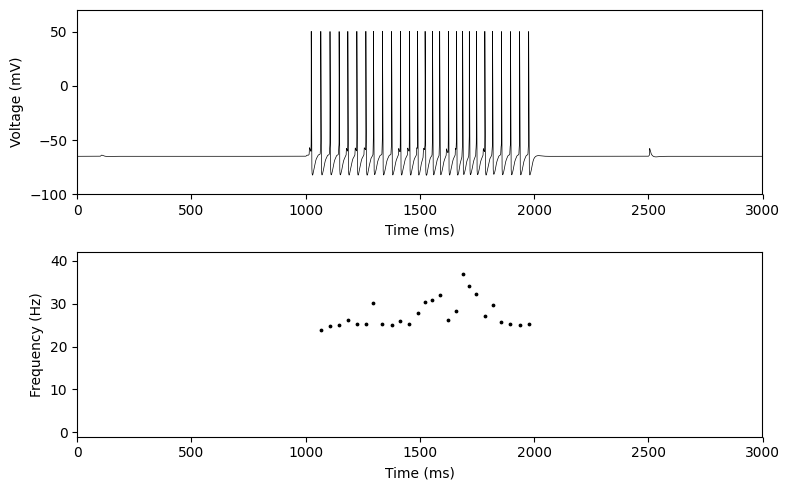

In [16]:
NeuronPlots.plot_spike_frequency(neuron)

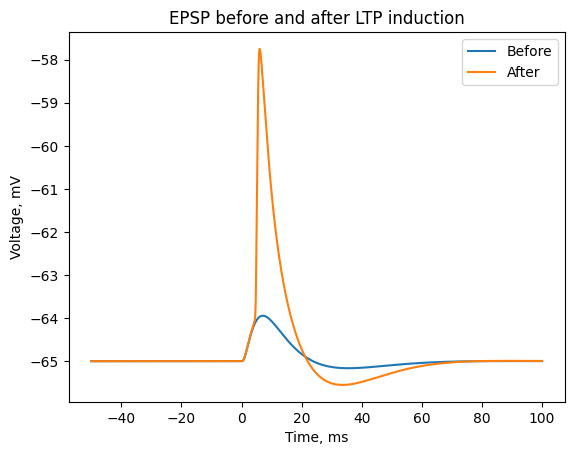

In [17]:
epsp_before = np.array(neuron.voltage[np.where(np.logical_and(neuron.time > test_stimulus_1 - time_before, neuron.time < test_stimulus_1 + time_after))[0]].tolist())
epsp_after = np.array(neuron.voltage[np.where(np.logical_and(neuron.time > test_stimulus_2 - time_before, neuron.time < test_stimulus_2 + time_after))[0]].tolist())

time = np.arange(-time_before, time_after + 0.025, 0.025)

plt.ylabel("Voltage, mV")
plt.xlabel("Time, ms")

plt.plot(
    time[:len(epsp_before)],
    epsp_before,
    label = "Before"
)

plt.plot(
    time[:len(epsp_after)],
    epsp_after,
    label = "After"
)

plt.title(f"EPSP before and after LTP induction")
plt.legend(loc = "upper right")
plt.grid(False)

plt.show()

In [18]:
NeuronUtils.set_stimulus(
    duration = ltp_duration + 200,
    delay = ltp_start - 100,
    frequency1 = 1000,
    frequency2 = 1005,
    amplitude = 134,
    phase = 10
)
neuron.set_initial_conductance(conductance)
neuron.run(duration = duration)

Neuron initialized
Elapsed time: 69.54 seconds


In [19]:
conductance

8.75e-05

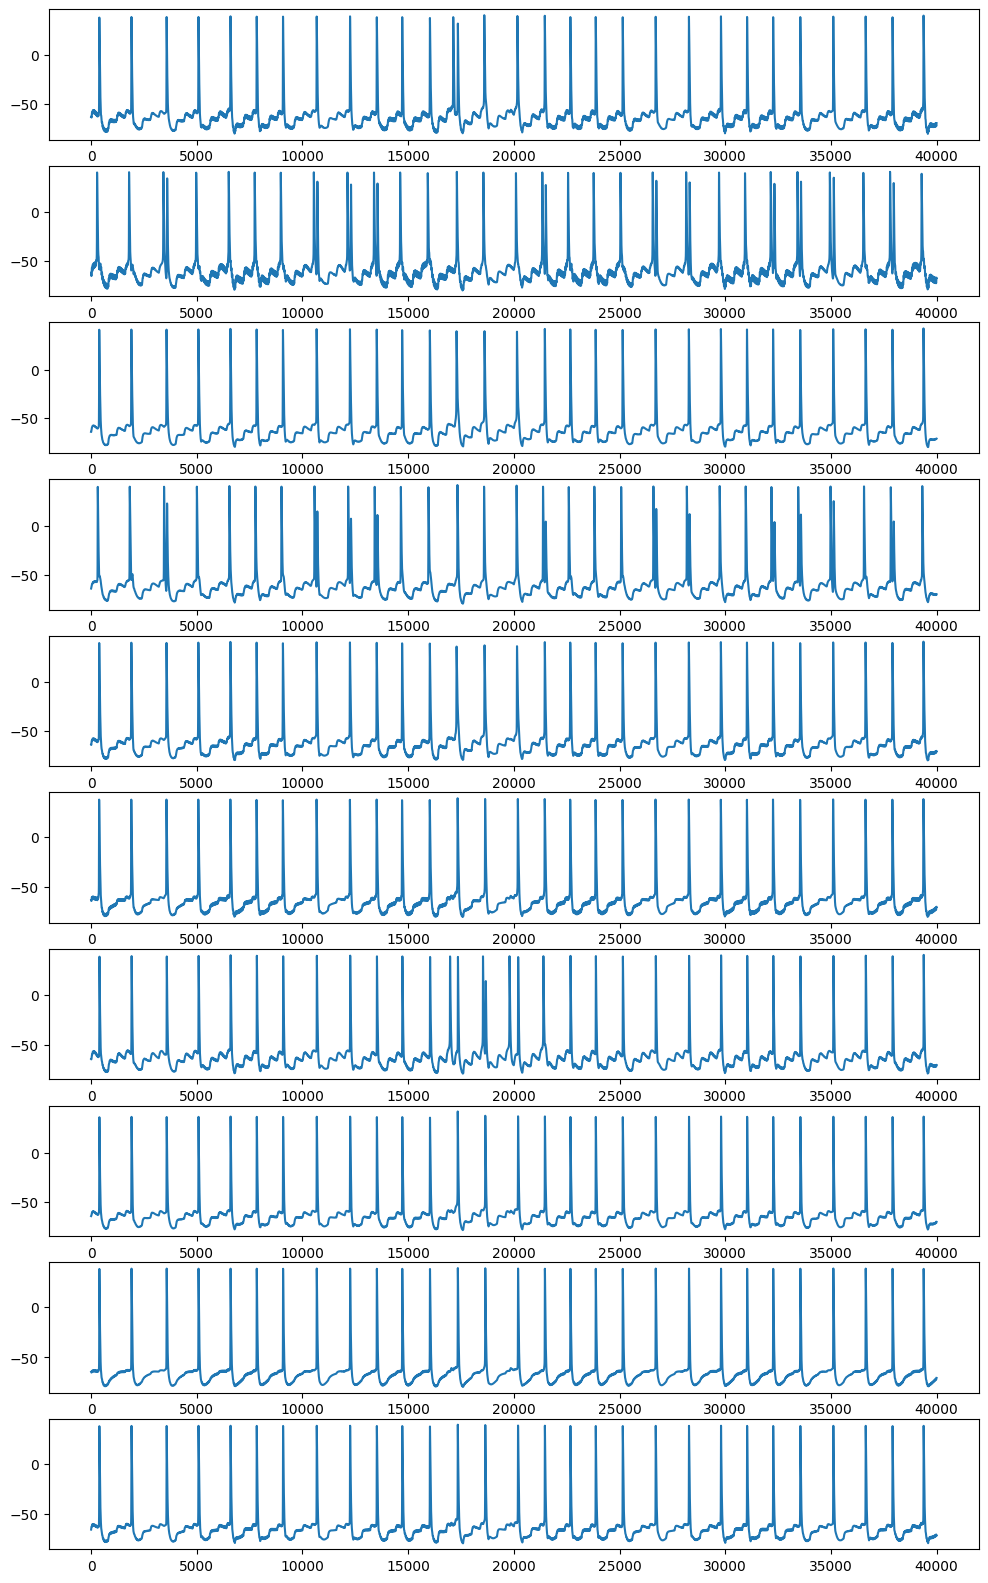

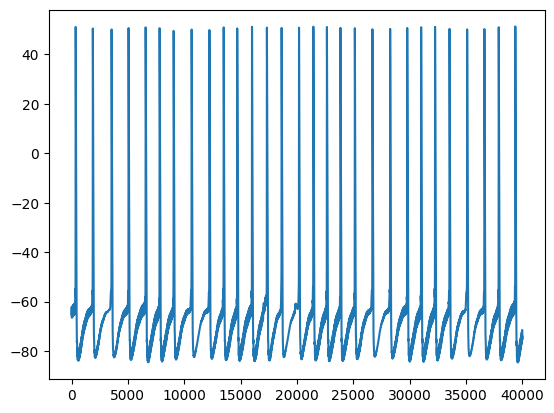

In [20]:
# Change of plans: want dendritic spikes during LTP (at least half the synapses?)
#                  and don't care whether the neuron spikes during LTP or not
ltp_time = np.logical_and(neuron.time > ltp_start, neuron.time < ltp_start + ltp_duration)
np.any(neuron.synapses[0].voltage[ ltp_time ] > -20)

fig, axs = plt.subplots(nrows = 10, ncols = 1, figsize = (12, 10 * 2))
for ax, synapse in zip(axs, neuron.synapses):
    ax.plot(
        synapse.voltage[ ltp_time ]
    )
plt.show()

plt.plot(neuron.voltage[ltp_time])

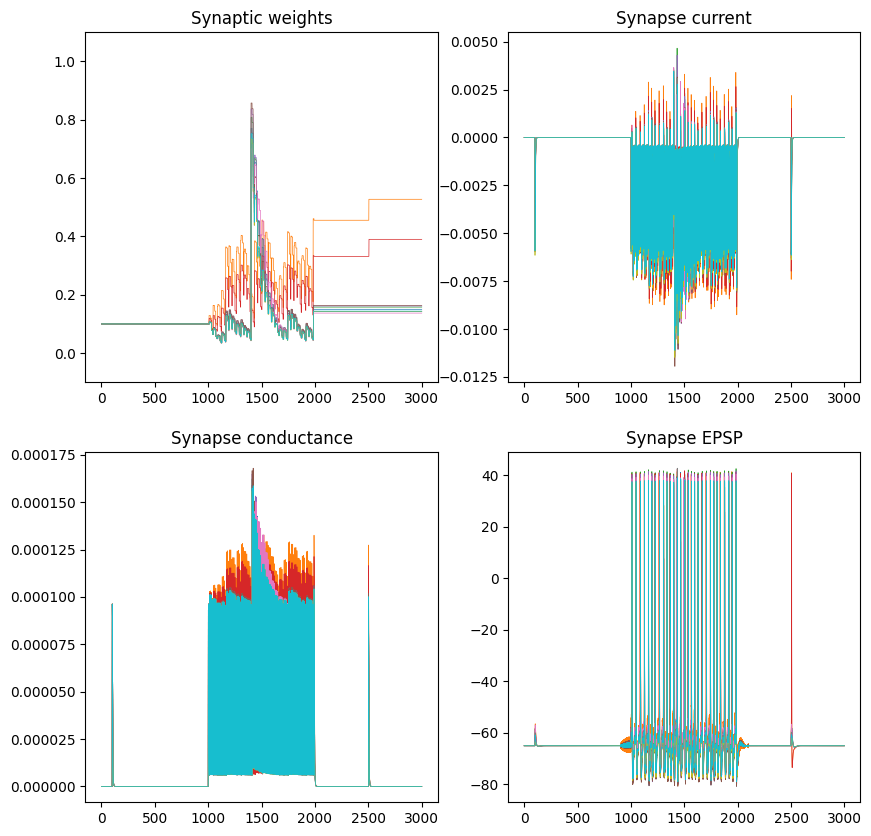

In [21]:
NeuronPlots.plot_all_synapses(neuron)

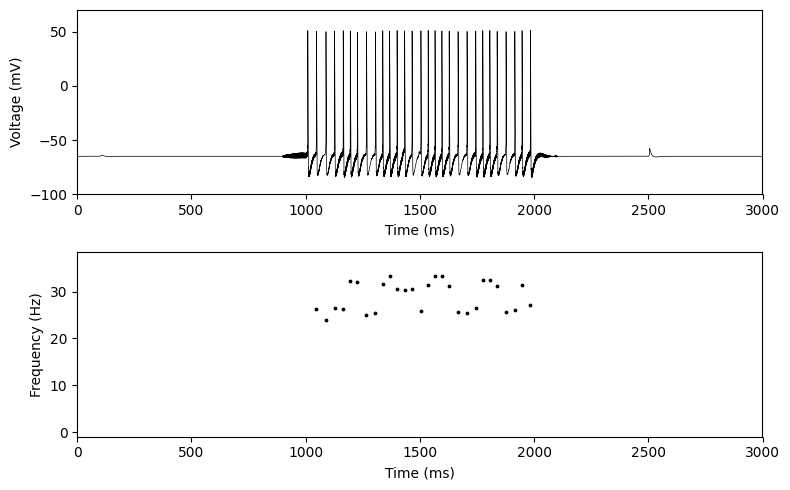

In [22]:
NeuronPlots.plot_spike_frequency(neuron)

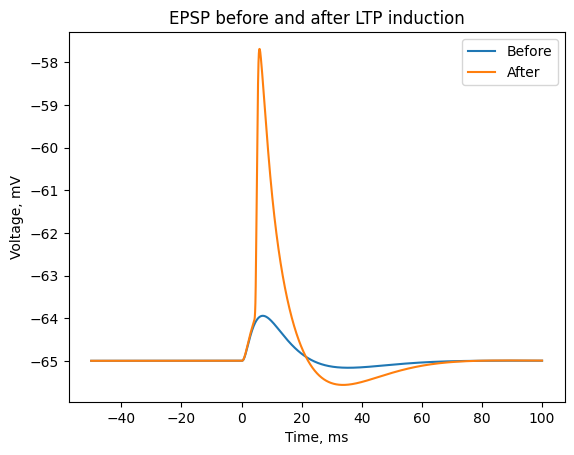

In [23]:
epsp_before = np.array(neuron.voltage[np.where(np.logical_and(neuron.time > test_stimulus_1 - time_before, neuron.time < test_stimulus_1 + time_after))[0]].tolist())
epsp_after = np.array(neuron.voltage[np.where(np.logical_and(neuron.time > test_stimulus_2 - time_before, neuron.time < test_stimulus_2 + time_after))[0]].tolist())

time = np.arange(-time_before, time_after + 0.025, 0.025)

plt.ylabel("Voltage, mV")
plt.xlabel("Time, ms")

plt.plot(
    time[:len(epsp_before)],
    epsp_before,
    label = "Before"
)

plt.plot(
    time[:len(epsp_after)],
    epsp_after,
    label = "After"
)

plt.title(f"EPSP before and after LTP induction")
plt.legend(loc = "upper right")
plt.grid(False)

plt.show()